In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
b = 0.5
x0 = 0.5

def quadratic(f,x_o,x_n, m):
  N = 2*m + 1
  x = np.linspace(x_o,x_n,N)
  h = x[1] - x[0]
  return (h*(f(x[0]) + f(x[-1]) + 4*np.sum(f(x[1:-1:2])) + 2*np.sum(f(x[2:-1:2])))/3)

def f(x):
    return (x**3)/(np.exp(x) - 1)

def w(x):
    return 1/((b + (x - x0)**2))

norm = quadratic(w, 0, 1, 5)

def w_(x):
    return w(x)/norm

def get_x(y): 
    
    return quadratic(w_, 0, y, 5)

def g(x):
    return f(x)/w_(x)

def MC_eval_f(n):
    store = 0.0
    for i in range(n):
        x = np.random.rand()
        store += f(x)
    return store/n

def MC_eval_g(n):
    store = 0.0
    for i in range(n):
        y = np.random.rand()
        store += g(get_x(y))
    return store/n

In [3]:
Ns = np.concatenate((np.asarray([5, 10, 15])*10, np.asarray([5, 10, 15])*100))

np.random.seed(20)
exact_value = quadratic(f, 1e-05, 1, 5)
for n in Ns:
    value1 = MC_eval_f(n)
    value2 = MC_eval_g(n)
    print(f"{n} {value1} {value2} {exact_value}")

50 0.22554942983398274 0.2474446482587699 0.22480621287951405
100 0.2700231245385401 0.2641677245934051 0.22480621287951405
150 0.2273698301660728 0.2219990992787892 0.22480621287951405
500 0.2044469958376843 0.24739459258983562 0.22480621287951405
1000 0.22262570131535597 0.2531735140635793 0.22480621287951405
1500 0.23106481468639045 0.24662383184778727 0.22480621287951405


1.7408497291514908


/tmp/ipykernel_2803/1127957305.py:11: RuntimeWarning: invalid value encountered in divide
  return (x**3)/(np.exp(x) - 1)


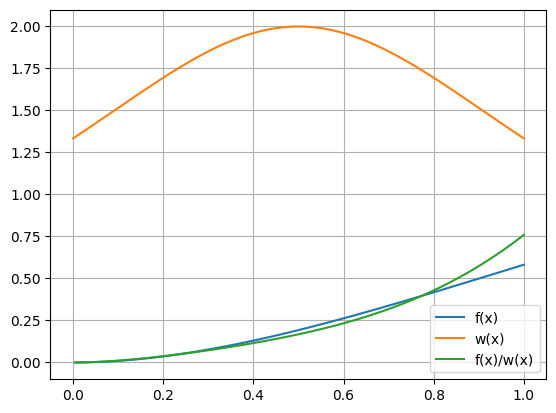

In [5]:
xs = np.linspace(0.0, 1.0, 200)
ys = f(xs)
plt.plot(xs, ys, label='f(x)')
ys = w(xs)
print(norm)
plt.plot(xs, ys, label='w(x)')
ys = g(xs)
plt.plot(xs, ys, label='f(x)/w(x)')
plt.grid()
plt.legend()

# Q2

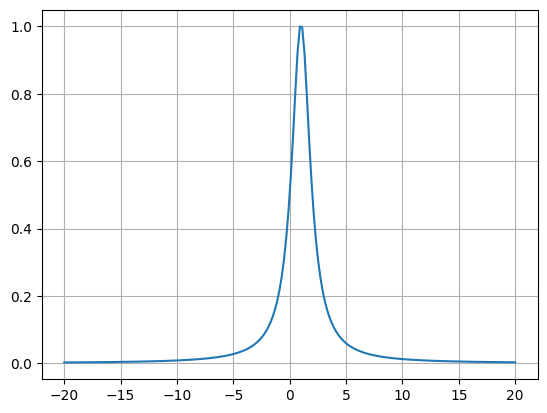

In [3]:
def w(x):
    
    return 1/(1 + (x - 1)**2)

xs = np.linspace(-20, 20.0, num=200)
ys = [w(x) for x in xs]

ys = ys/np.max(ys)
plt.plot(xs, ys);
plt.grid()

In [4]:
# Simulate

x0 = 0.5
N = 1000000
stepsize = 2.0

store = np.zeros(N)
for i in range(N):
    store[i] = x0
    p = np.random.rand()
    x1 = x0 + stepsize*(np.random.rand()- 0.5)
    a = min(1, w(x1)/w(x0))
    if p<a:
        x0 = x1

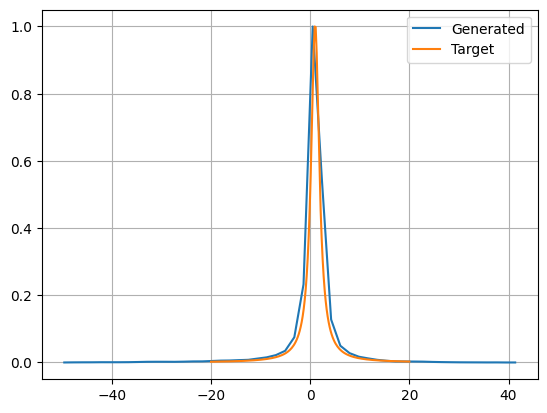

In [5]:
values, edges = np.histogram(store,50)
midpoints = [(edges[i]+edges[i+1])/2 for i in range(len(edges)-1)]

values = values/np.max(values)
plt.plot(midpoints, values,label='Generated')
plt.plot(xs, ys,label='Target')
plt.grid()
plt.legend()